# Regularization Methods

In this mini-project, two regularization methods, "Dropout" method and "L1L2" method is tested on a simple model for classification of a twp-labeled and two-dimensional dataset.

## Importing the packages

In [9]:
import os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import keras
from keras import regularizers

from sklearn.inspection import DecisionBoundaryDisplay

In [10]:
os.environ["KERAS_BACKEND"] = "tensorflow"

## Loading datasets

In [11]:
data_train_x = np.load("data/data_X.npy")
data_train_y = np.load("data/data_y.npy")
data_eval_x = np.load("data/data_eval_X.npy")
data_eval_y = np.load("data/data_eval_y.npy")

print(data_train_x.shape, data_train_y.shape, data_eval_x.shape, data_eval_y.shape)

(211, 2) (211, 1) (200, 2) (200, 1)


This dataset contain a two-dimensional set of points with the label 0 or 1.

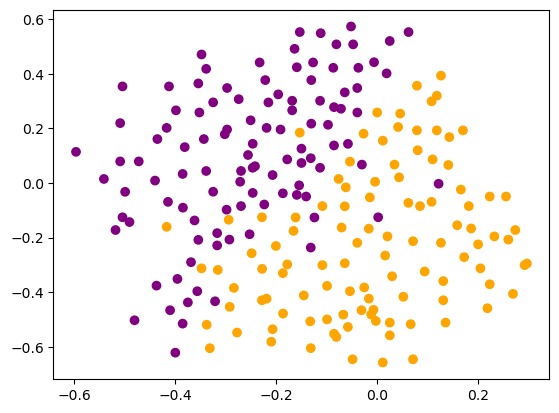

In [12]:
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors)

## Simple Model without regularization

In this model, we don't use any regularization methods. This neural network has 4 layers, with 4000 neurons in the first three layers. The output layer uses `sigmoid` activation function and the other layers use `ReLu`. The output layer has only one neuron due to the fact that this is a two-class problem.

The amount of neurons is a lot for a simple two-dimensional dataset, but with such a complicated model, we can see how overfitting occurs and then, how can we use regularization to avoid it.

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')])

In this model, we use binary crossentropy loss function and "Adam" optimizer.

In [14]:
model.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [15]:
history = model.fit(data_train_x, data_train_y,
                    epochs=500, batch_size=32,
                    validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.7820 - loss: 0.4765 - val_accuracy: 0.8800 - val_loss: 0.4107
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.8720 - loss: 0.3693 - val_accuracy: 0.9100 - val_loss: 0.3357
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.9100 - loss: 0.2454 - val_accuracy: 0.9350 - val_loss: 0.2608
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.9289 - loss: 0.2200 - val_accuracy: 0.9150 - val_loss: 0.3069
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.9242 - loss: 0.2244 - val_accuracy: 0.9300 - val_loss: 0.3085
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 401ms/step - accuracy: 0.9384 - loss: 0.2190 - val_accuracy: 0.9250 - val_loss: 0.3012
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 344ms/step - accuracy: 0.9289 - loss: 0.2170 - val_accuracy: 0.9300 - val_loss: 0.2881
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 365ms/step - accuracy: 0.9336 - loss: 0.2102 - val_accuracy: 0.9200 - v

After training the model, we use the function below to draw the plot of "Loss" and "Accuracy" over epochs, for both evaluation and training datasets.

In [16]:
def plot_loss_acc(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    
    epochs = range(1, len(train_loss) + 1)
    
    fig, axs = plt.subplots(2, figsize=(10, 7))
    fig.suptitle('Training and Validation Metrics')
    
    # Loss plot
    axs[0].plot(epochs, train_loss, label='Training loss', c='red')
    axs[0].plot(epochs, val_loss, label='Validation loss', c='blue')
    axs[0].set_title('Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].set_ylim([0, 1.5])
    
    # Accuracy plot
    axs[1].plot(epochs, train_acc, label='Training accuracy', c='red')
    axs[1].plot(epochs, val_acc, label='Validation accuracy', c='blue')
    axs[1].set_title('Accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    
    plt.subplots_adjust(hspace=0.5)
    plt.show()

And we then use the function below to draw the classified boundaries in 2 dimensional space.

In [17]:
def get_decision_boundaries(model, xmin, xmax, ymin, ymax, steps):
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)
    points = (np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32))

    z = (model.predict(np.c_[xx.ravel(), yy.ravel()])>0.5).reshape(xx.shape)

    return xx, yy, z

def plt_decision_boundaries(model, x_min, x_max, y_min, y_max, steps):
    plt.figure(figsize=(6, 4))
    xx, yy, z = get_decision_boundaries(model, x_min, x_max, y_min, y_max, steps)
    plt.contourf(xx, yy, z, alpha=0.2, cmap=matplotlib.colors.ListedColormap(["C1", "C0"]));

Using the functions above, we first draw the plots, and then the classified regions of the model.

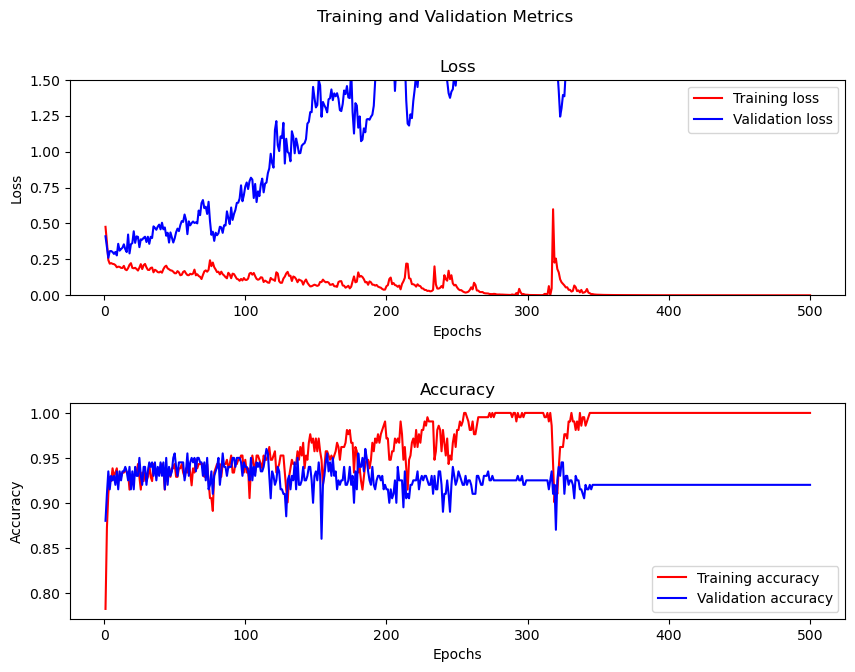

In [18]:
plot_loss_acc(history)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


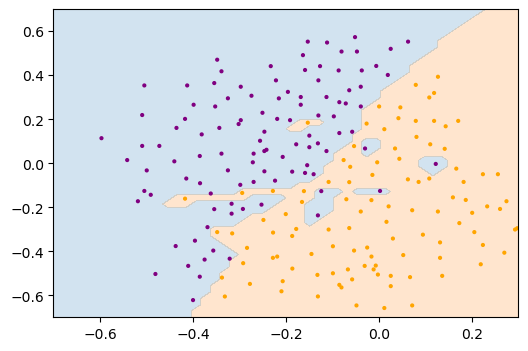

In [19]:
plt_decision_boundaries(model, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## Dropout regularization

This time, we use the "Dropout" regularization method while training the model to avoid overfitting. The structure of network, and optimizing methods are the same as before.

In [20]:
model_dropout = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(1, activation='sigmoid')])

In [21]:
model_dropout.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [ ]:
history_dropout = model_dropout.fit(data_train_x, data_train_y,
                            epochs=500, batch_size=32,
                            validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 488ms/step - accuracy: 0.7725 - loss: 0.5217 - val_accuracy: 0.8750 - val_loss: 0.4170
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 354ms/step - accuracy: 0.8863 - loss: 0.3051 - val_accuracy: 0.8900 - val_loss: 0.4139
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step - accuracy: 0.9052 - loss: 0.2561 - val_accuracy: 0.9200 - val_loss: 0.3313
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - accuracy: 0.9100 - loss: 0.2466 - val_accuracy: 0.9200 - val_loss: 0.3078
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 385ms/step - accuracy: 0.9147 - loss: 0.2336 - val_accuracy: 0.9400 - val_loss: 0.2900
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.9147 - loss: 0.2271 - val_accuracy: 0.9100 - val_loss: 0.3144
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.8957 - loss: 0.2490 - val_accuracy: 0.8950 - val_loss: 0.3703
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.9100 - loss: 0.2318 - val_accuracy: 0.9200 - v

Now we draw the plots and regions for this model.

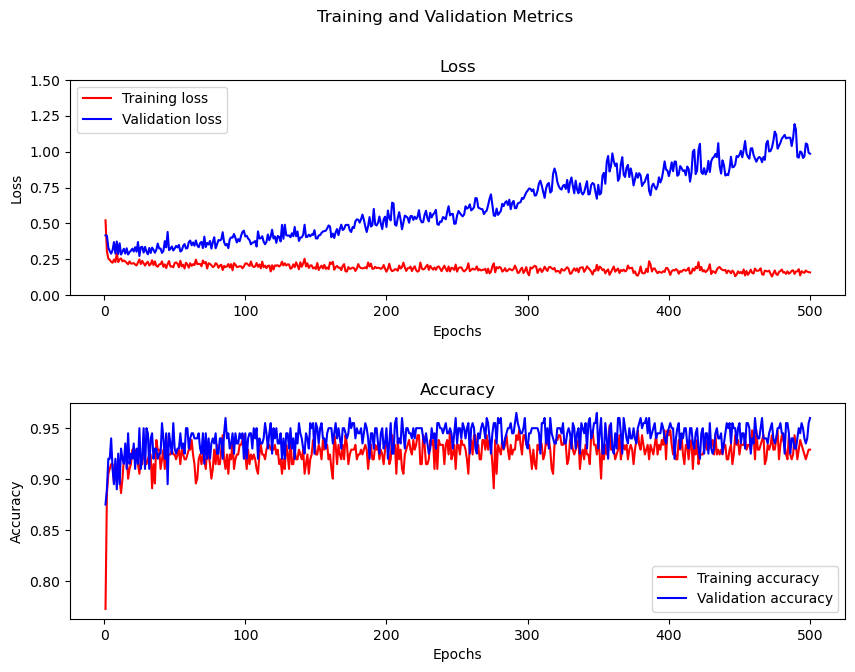

In [ ]:
plot_loss_acc(history_dropout)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


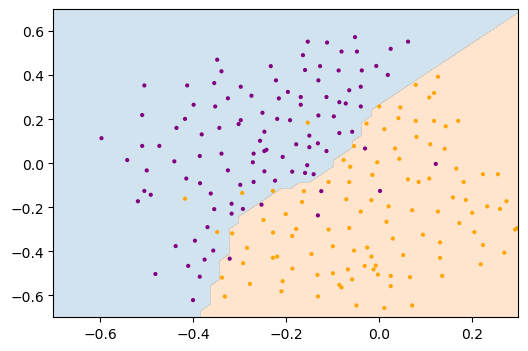

In [24]:
plt_decision_boundaries(model_dropout, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L1 regularization

In [30]:
model_l1 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L1(3e-5))
    ])

In [31]:
model_l1.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [32]:
history_l1 = model_l1.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.7583 - loss: 11.5581 - val_accuracy: 0.8500 - val_loss: 8.4609
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step - accuracy: 0.9100 - loss: 6.8740 - val_accuracy: 0.8950 - val_loss: 4.8847
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 477ms/step - accuracy: 0.9100 - loss: 3.7909 - val_accuracy: 0.9200 - val_loss: 2.5892
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 468ms/step - accuracy: 0.9100 - loss: 2.1025 - val_accuracy: 0.9250 - val_loss: 1.6722
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 467ms/step - accuracy: 0.9147 - loss: 1.5687 - val_accuracy: 0.9050 - val_loss: 1.3554
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.9242 - loss: 1.1356 - val_accuracy: 0.9250 - val_loss: 0.9296
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 0.9100 - loss: 0.8676 - val_accuracy: 0.9200 - val_loss: 0.7685
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 615ms/step - accuracy: 0.9100 - loss: 0.7071 - val_accuracy: 0.9100 - 

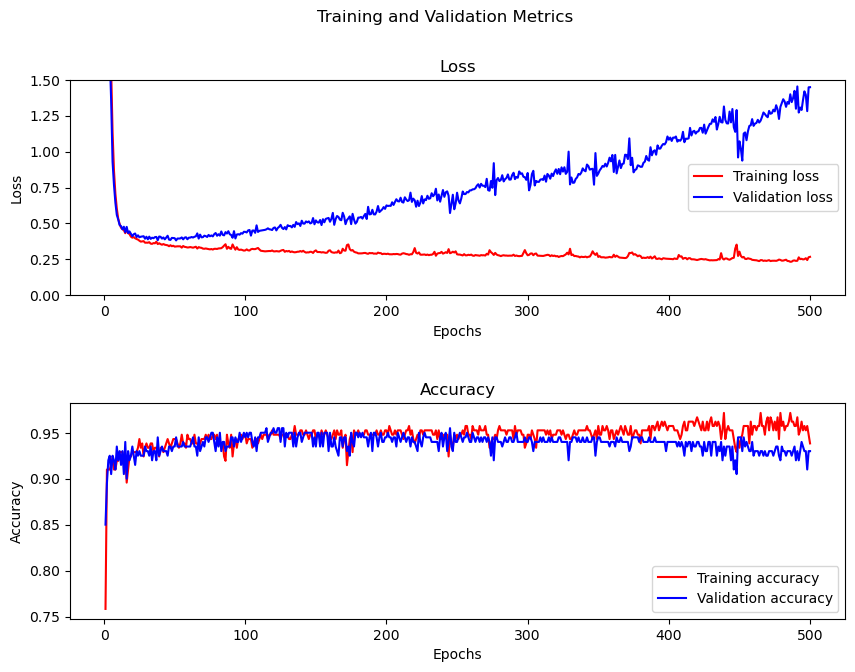

In [33]:
plot_loss_acc(history_l1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


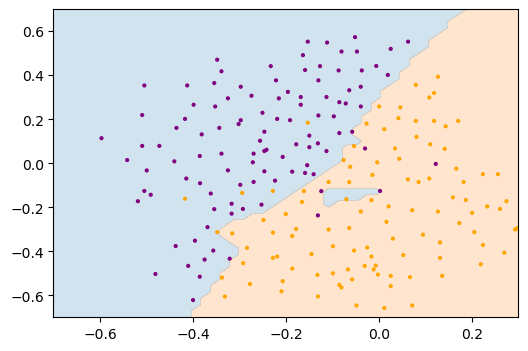

In [34]:
plt_decision_boundaries(model_l1, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L2 regularization

In [35]:
model_l2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L2(3e-4))
    ])

In [36]:
model_l2.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [37]:
history_l2 = model_l2.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 507ms/step - accuracy: 0.7441 - loss: 2.4650 - val_accuracy: 0.8600 - val_loss: 1.9082
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step - accuracy: 0.9005 - loss: 1.4456 - val_accuracy: 0.9300 - val_loss: 1.1066
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 413ms/step - accuracy: 0.8863 - loss: 0.9410 - val_accuracy: 0.9150 - val_loss: 0.7698
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.9194 - loss: 0.6469 - val_accuracy: 0.9300 - val_loss: 0.5706
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.9005 - loss: 0.5197 - val_accuracy: 0.9250 - val_loss: 0.5049
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 415ms/step - accuracy: 0.9242 - loss: 0.4396 - val_accuracy: 0.9250 - val_loss: 0.4324
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step - accuracy: 0.9289 - loss: 0.3811 - val_accuracy: 0.9450 - val_loss: 0.3818
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 433ms/step - accuracy: 0.9242 - loss: 0.3449 - val_accuracy: 0.9250 - v

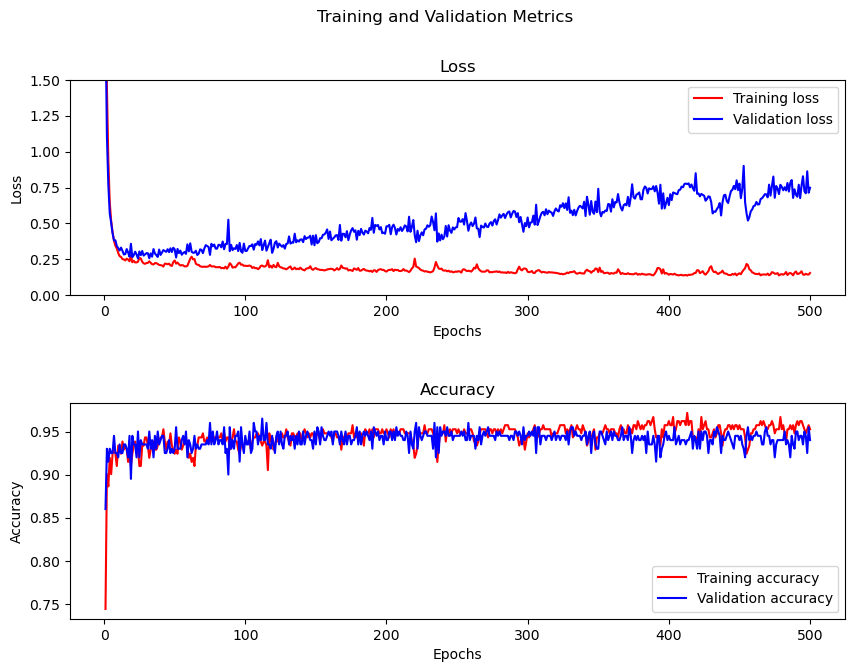

In [38]:
plot_loss_acc(history_l2)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


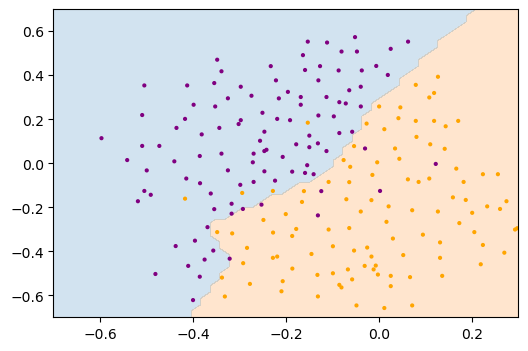

In [39]:
plt_decision_boundaries(model_l2, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L1L2 regularization

In [25]:
model_l1l2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4))
    ])

In [26]:
model_l1l2.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [ ]:
history_l1l2 = model_l1l2.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 622ms/step - accuracy: 0.7536 - loss: 13.2884 - val_accuracy: 0.8550 - val_loss: 9.4086
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 522ms/step - accuracy: 0.8531 - loss: 7.4876 - val_accuracy: 0.9050 - val_loss: 5.1058
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 524ms/step - accuracy: 0.8863 - loss: 3.9280 - val_accuracy: 0.9250 - val_loss: 2.5979
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.9289 - loss: 2.0764 - val_accuracy: 0.9350 - val_loss: 1.6180
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step - accuracy: 0.9100 - loss: 1.5406 - val_accuracy: 0.9250 - val_loss: 1.3301
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.8910 - loss: 1.1625 - val_accuracy: 0.9000 - val_loss: 0.9297
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 520ms/step - accuracy: 0.9194 - loss: 0.8330 - val_accuracy: 0.9400 - val_loss: 0.7437
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 517ms/step - accuracy: 0.9242 - loss: 0.6791 - val_accuracy: 0.9250 - 

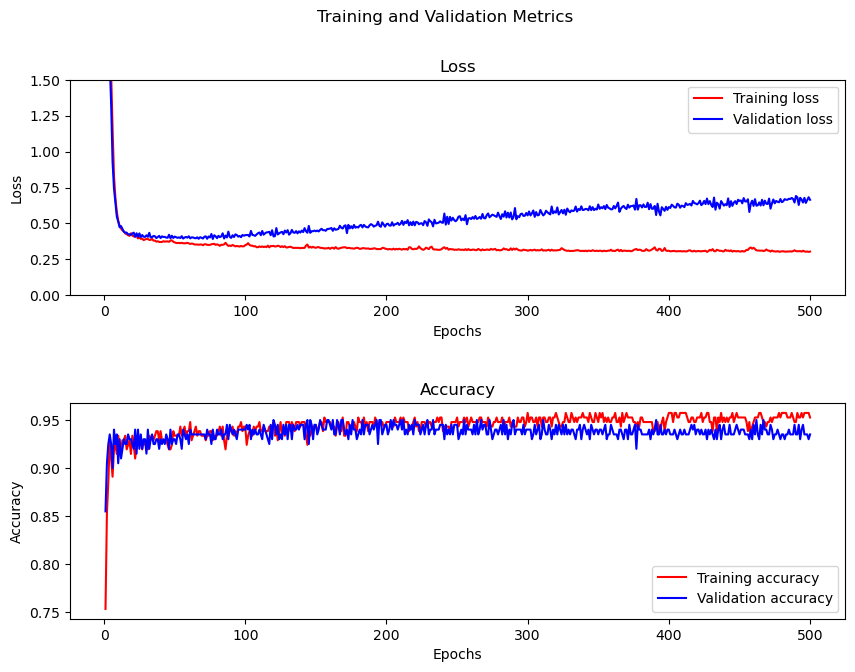

In [ ]:
plot_loss_acc(history_l1l2)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


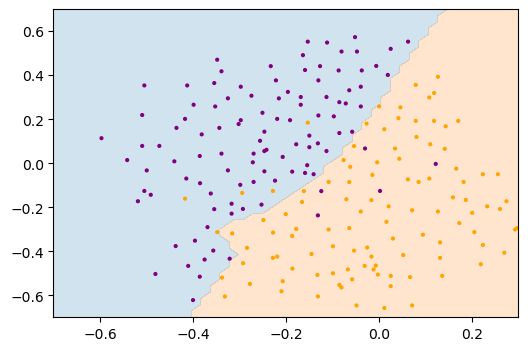

In [41]:
plt_decision_boundaries(model_l1l2, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## Overall comparison and evaluation

In [50]:
def plot_loss_acc_on_axes(history, ax_loss, ax_acc, title=""):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    
    epochs = range(1, len(train_loss) + 1)
    
    # Loss plot
    ax_loss.plot(epochs, train_loss, label='Training loss', c='red')
    ax_loss.plot(epochs, val_loss, label='Validation loss', c='blue')
    ax_loss.set_title(f'{title} - Loss')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.set_ylim([0, 1.5])
    
    # Accuracy plot
    ax_acc.plot(epochs, train_acc, label='Training accuracy', c='red')
    ax_acc.plot(epochs, val_acc, label='Validation accuracy', c='blue')
    ax_acc.set_title(f'{title} - Accuracy')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

In [ ]:
def get_decision_boundaries(model, xmin, xmax, ymin, ymax, steps):
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)
    points = (np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32))

    z = (model.predict(np.c_[xx.ravel(), yy.ravel()])>0.5).reshape(xx.shape)

    return xx, yy, z

def plot_decision_boundary_on_axes(model, ax, x_min, x_max, y_min, y_max, steps,
                                    data_x, data_y, title=""):
    xx, yy, z = get_decision_boundaries(model, x_min, x_max, y_min, y_max, steps)
    ax.contourf(xx, yy, z, alpha=0.2)
    colors = ['orange' if label == 0 else 'purple' for label in data_y.ravel()]
    ax.scatter(data_x[:, 0], data_x[:, 1], c=colors, s=4, edgecolors='none')
    ax.set_title(title)
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

In [53]:
# models = [model, model_l1, model_l2, model_l1l2, model_dropout]
# histories = [history, history_l1, history_l2, history_l1l2, history_dropout]
# model_names = ['Simple Neural Network', 'Regularized with L1', 'Regularized with L2', 'Regularized with L1L2', 'Regulatized with Dropout']

models = [model, model_l1, model_l2]
histories = [history, history_l1, history_l2]
model_names = ['Simple Neural Network', 'Regularized with L1', 'Regularized with L2']

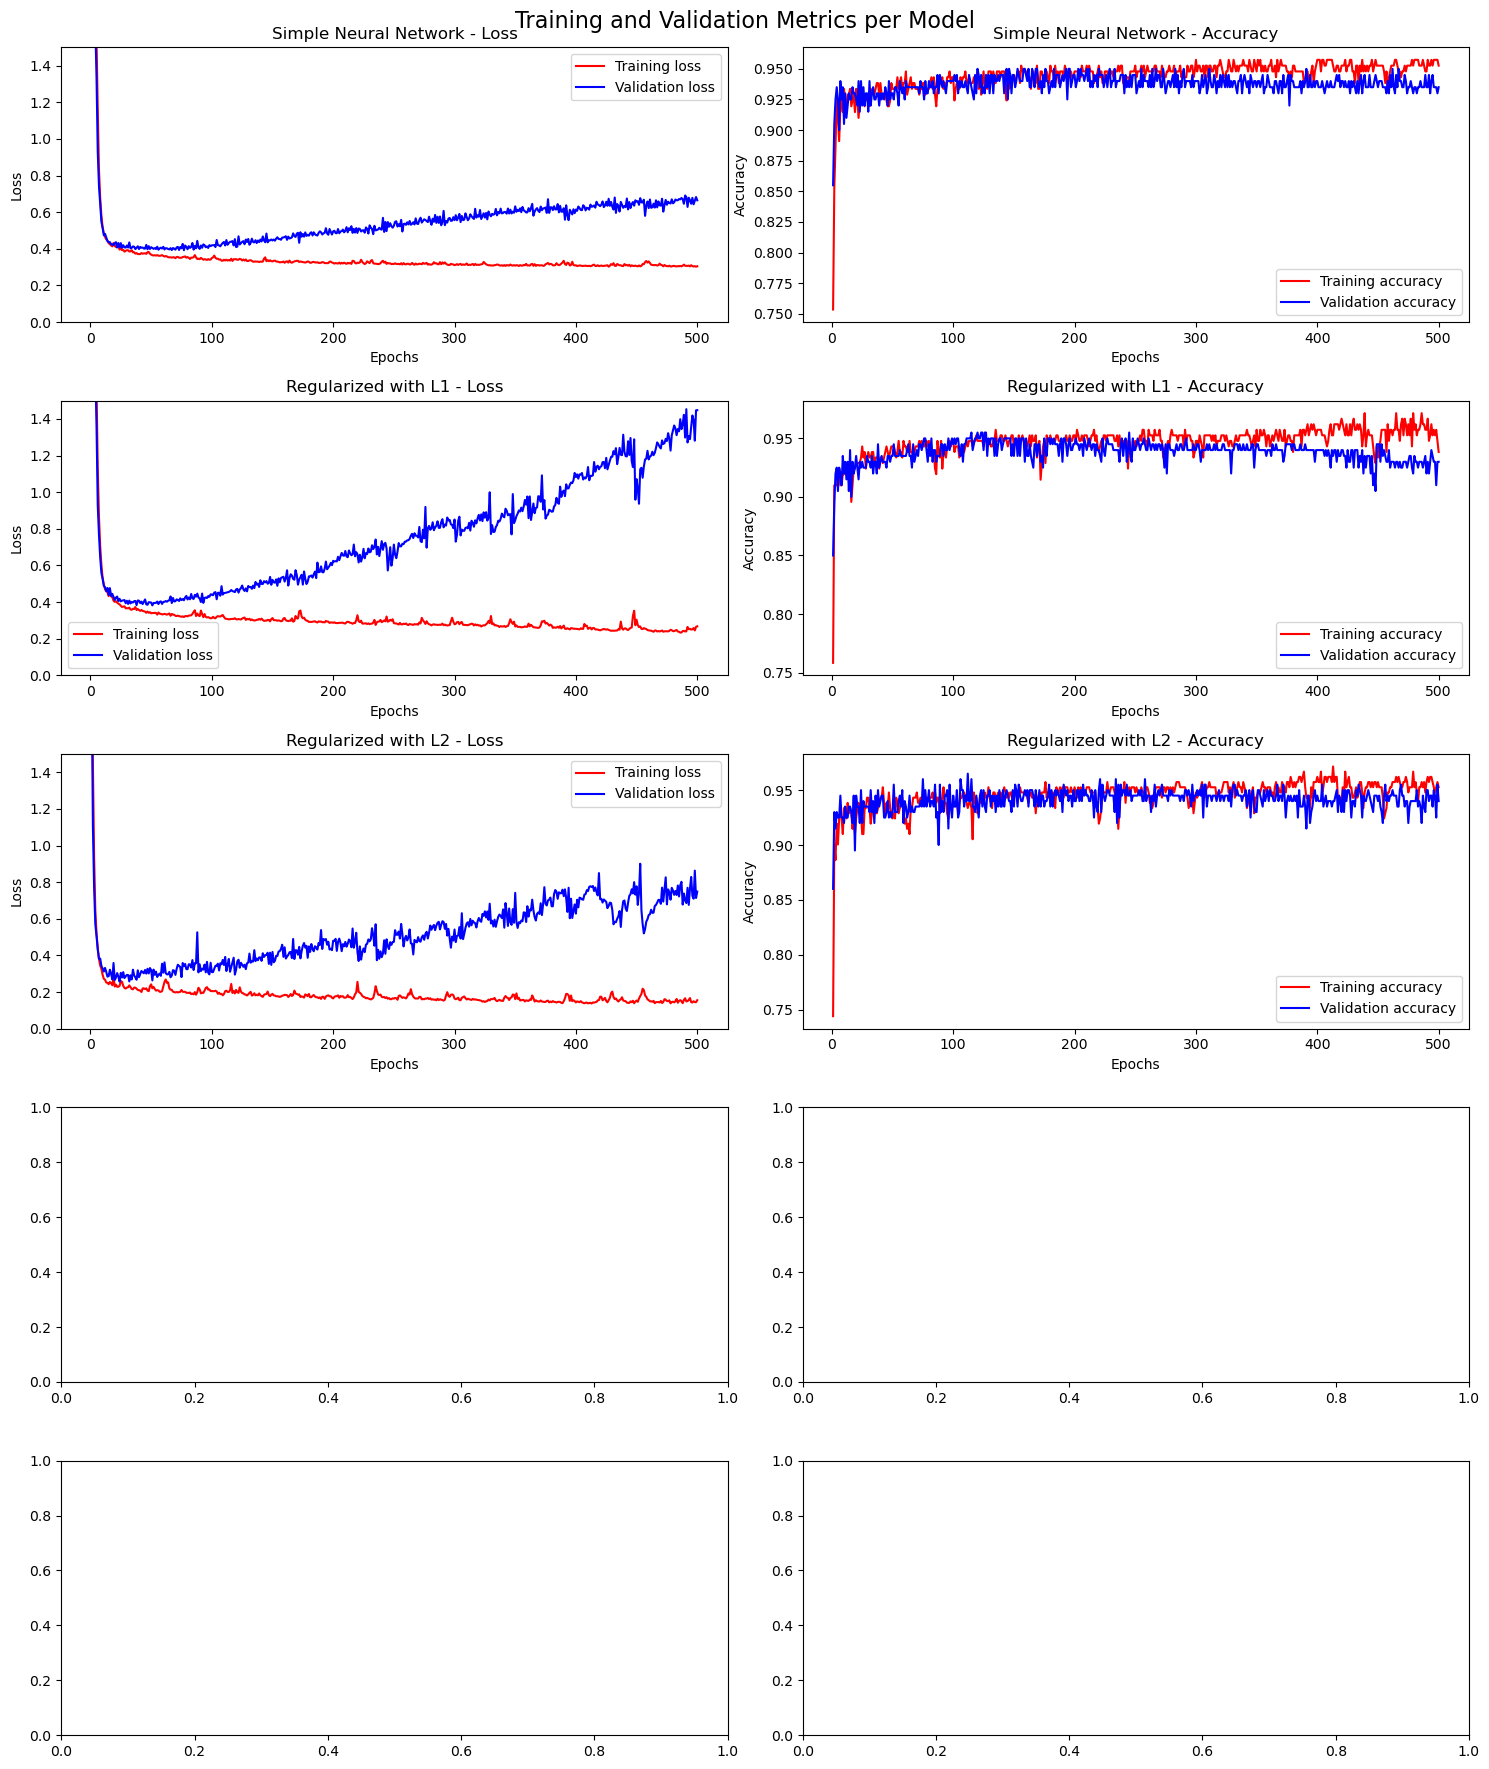

In [55]:
fig1, axes1 = plt.subplots(5, 2, figsize=(15, 18))
fig1.suptitle('Training and Validation Metrics per Model', fontsize=16)

for i, (hist, name) in enumerate(zip(histories, model_names)):
    ax_loss = axes1[i, 0]
    ax_acc = axes1[i, 1]
    plot_loss_acc_on_axes(hist, ax_loss, ax_acc, title=name)

plt.tight_layout()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


AttributeError: module 'matplotlib.colors' has no attribute 'ListedColorMap'

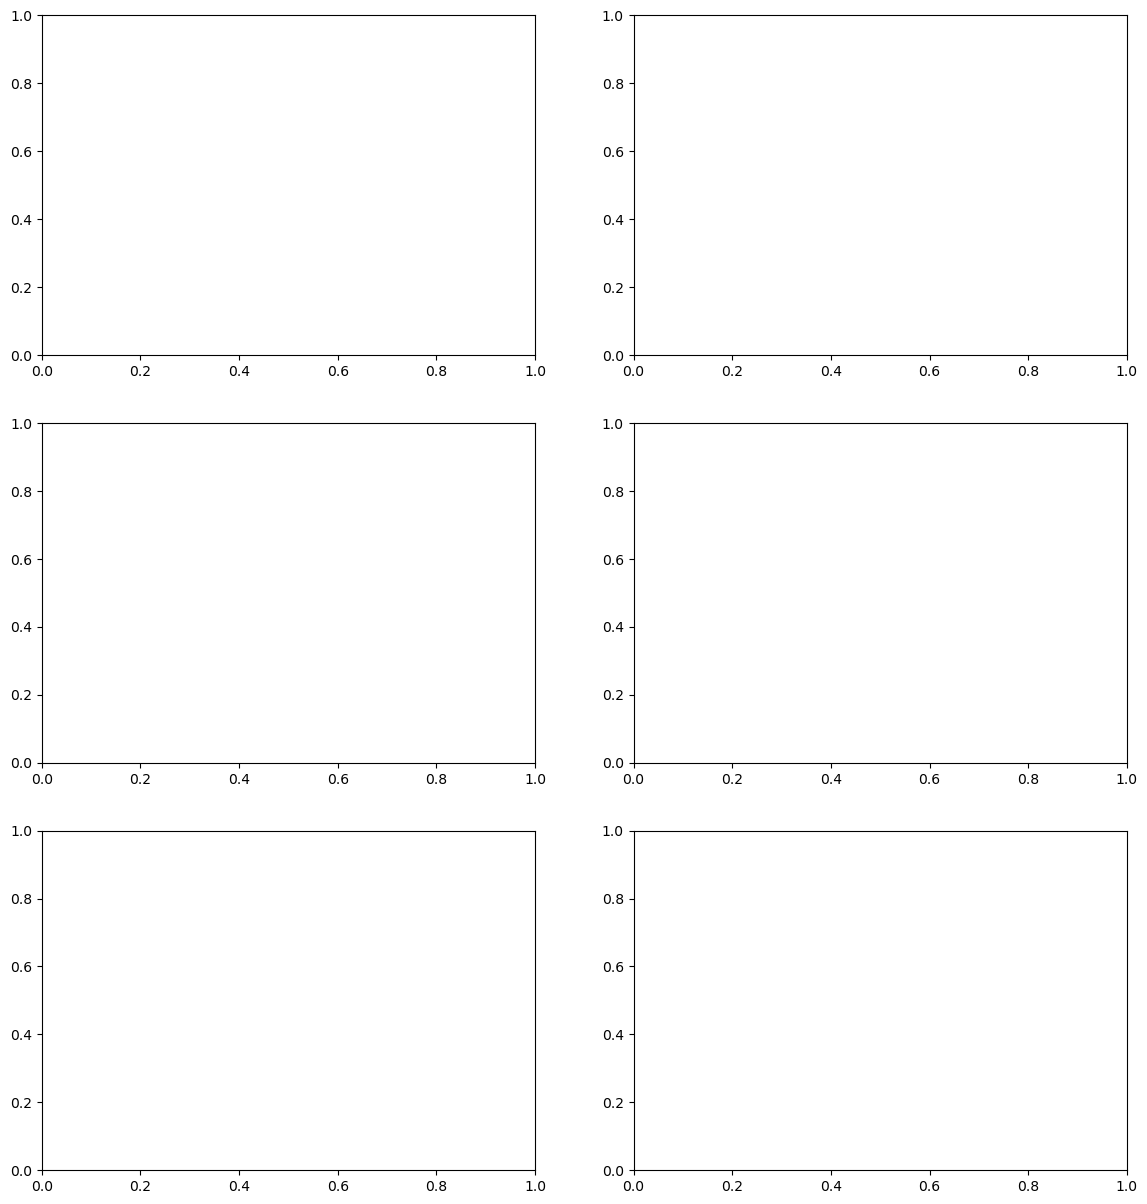

In [57]:
fig2, axes2 = plt.subplots(3, 2, figsize=(14, 15))
fig1.suptitle('Decision Boundaries', fontsize=16)


for i, (model, name) in enumerate(zip(models, model_names)):
    row = 1 // 2
    col = i % 2
    ax = axes2[row, col]
    plot_decision_boundary_on_axes(
        model, ax,
        x_min=-0.7, x_max=0.3, y_min=-0.7, y_max=0.7, steps=50,
        data_x=data_train_x, data_y=data_train_y,
        title=name
    )

axes2[2, 1].axis('off')

plt.tight_layout()
plt.show()